In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
X_train = np.load('/content/drive/MyDrive/X_train_aug.npy')
X_test = np.load('/content/drive/MyDrive/X_test_aug.npy')

y_train = np.load('/content/drive/MyDrive/y_train_aug.npy')
y_test = np.load('/content/drive/MyDrive/y_test_aug.npy')

In [ ]:
import numpy as np

def extract_features(signal):
    return [
        np.mean(signal),
        np.std(signal),
        np.max(signal),
        np.min(signal),
        np.sum(signal**2),
    ]

In [ ]:
X_train_feat = np.array([extract_features(x) for x in X_train])
X_test_feat = np.array([extract_features(x) for x in X_test])

In [ ]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(max_iter=1000,class_weight='balanced')
model2.fit(X_train_feat, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred2 = model2.predict(X_test_feat)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy: 0.4991
              precision    recall  f1-score   support

         0.0       0.60      0.51      0.55      6000
         1.0       0.40      0.48      0.43      4000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.52      0.50      0.50     10000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=1,
    random_state=42
)

model3.fit(X_train_feat, y_train)

RandomForestClassifier(max_depth=4, max_features=1, min_samples_leaf=10,
                       min_samples_split=20, n_estimators=50, random_state=42)

In [ ]:
y_pred3 = model3.predict(X_test_feat)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Accuracy: 0.6622
              precision    recall  f1-score   support

         0.0       0.64      0.99      0.78      6000
         1.0       0.94      0.17      0.28      4000

    accuracy                           0.66     10000
   macro avg       0.79      0.58      0.53     10000
weighted avg       0.76      0.66      0.58     10000



In [ ]:
train_acc = model3.score(X_train_feat, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.663875


In [ ]:
test_acc = model3.score(X_test_feat, y_test)
print("Testing Accuracy:", test_acc)

Testing Accuracy: 0.6622


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model3, X_train_feat, y_train, cv=5)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.66275  0.66325  0.660375 0.6655   0.662875]
Mean CV Accuracy: 0.6629500000000002


In [ ]:
model4 = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=1,
    random_state=42
)
model4.fit(X_train_feat, y_train)

RandomForestClassifier(max_depth=4, max_features=1, min_samples_leaf=10,
                       min_samples_split=20, random_state=42)

In [ ]:
y_pred4 = model4.predict(X_test_feat)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred4))
print(classification_report(y_test, y_pred4))

Accuracy: 0.662
              precision    recall  f1-score   support

         0.0       0.64      0.99      0.78      6000
         1.0       0.94      0.17      0.28      4000

    accuracy                           0.66     10000
   macro avg       0.79      0.58      0.53     10000
weighted avg       0.76      0.66      0.58     10000



In [ ]:
model5 = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=1,
    random_state=42
)
model5.fit(X_train_feat, y_train)

RandomForestClassifier(max_depth=4, max_features=1, min_samples_leaf=10,
                       min_samples_split=20, n_estimators=150, random_state=42)

In [ ]:
y_pred4 = model5.predict(X_test_feat)
print("Accuracy:", accuracy_score(y_test, y_pred4))
print(classification_report(y_test, y_pred4))

Accuracy: 0.6617
              precision    recall  f1-score   support

         0.0       0.64      0.99      0.78      6000
         1.0       0.94      0.16      0.28      4000

    accuracy                           0.66     10000
   macro avg       0.79      0.58      0.53     10000
weighted avg       0.76      0.66      0.58     10000



In [ ]:
model6 = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=1,
    random_state=42
)
model6.fit(X_train_feat, y_train)
y_pred6 = model6.predict(X_test_feat)
print("Accuracy:", accuracy_score(y_test, y_pred6))
print(classification_report(y_test, y_pred6))

Accuracy: 0.6614
              precision    recall  f1-score   support

         0.0       0.64      0.99      0.78      6000
         1.0       0.95      0.16      0.28      4000

    accuracy                           0.66     10000
   macro avg       0.79      0.58      0.53     10000
weighted avg       0.76      0.66      0.58     10000



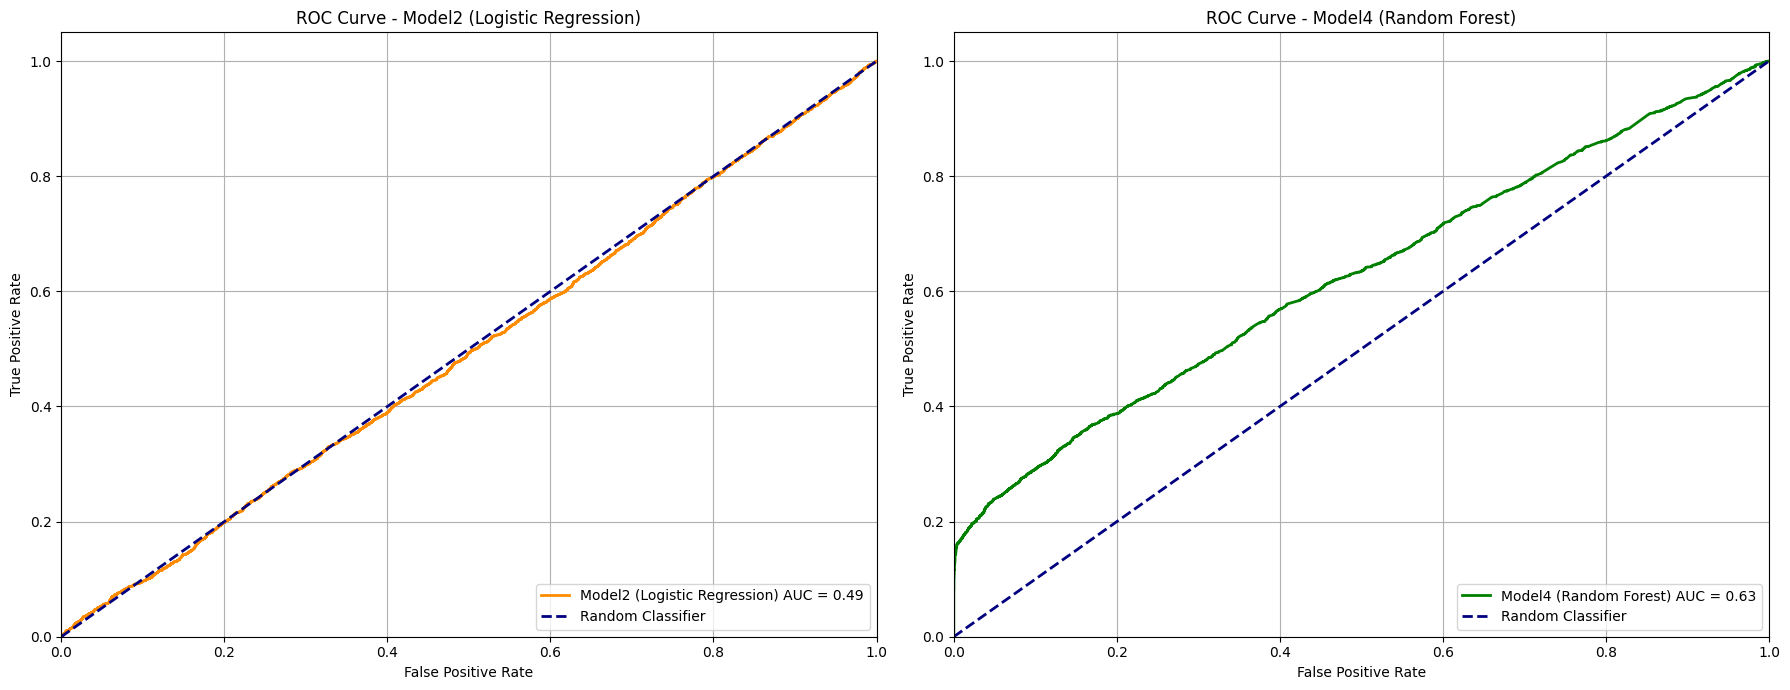

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for model2 (Logistic Regression)
y_pred_proba2 = model2.predict_proba(X_test_feat)[:, 1]

# Get predicted probabilities for model4 (Random Forest)
y_pred_proba4 = model4.predict_proba(X_test_feat)[:, 1]

# Calculate ROC curve and AUC for model2
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_pred_proba2)
roc_auc2 = auc(fpr2, tpr2)

# Calculate ROC curve and AUC for model4
fpr4, tpr4, thresholds4 = roc_curve(y_test, y_pred_proba4)
roc_auc4 = auc(fpr4, tpr4)

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot ROC curve for Model2 on the first subplot
axes[0].plot(fpr2, tpr2, color='darkorange', lw=2, label=f'Model2 (Logistic Regression) AUC = {roc_auc2:.2f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Model2 (Logistic Regression)')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Plot ROC curve for Model4 on the second subplot
axes[1].plot(fpr4, tpr4, color='green', lw=2, label=f'Model4 (Random Forest) AUC = {roc_auc4:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Model4 (Random Forest)')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()